# D2Q9 Order Study

This notebook audits whether the current periodic BGK D2Q9 Taylor-Green implementation behaves like a second-order method before we consider replacing it with an incompressible, TRT, or MRT variant.

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import matplotlib.pyplot as plt

from pq_cfd import d2q9_order_cases, run_d2q9_order_study, write_d2q9_order_csv

In [2]:
output_dir = project_root / ".cache" / "benchmarks"
output_dir.mkdir(parents=True, exist_ok=True)

cases = d2q9_order_cases(tau_values=(0.6, 0.8, 1.0), amplitude=0.02)
records = run_d2q9_order_study(cases)
csv_path = write_d2q9_order_csv(records, output_dir / "d2q9_order_study.csv")

print(f"cases: {len(records)}")
print(f"CSV output: {csv_path}")
print(f"stable cases: {sum(record.stable for record in records)} / {len(records)}")

cases: 12
CSV output: c:\Users\NishchayVORA\Documents\PQ_CFD\.cache\benchmarks\d2q9_order_study.csv
stable cases: 12 / 12


In [3]:
def plot_error_with_guides(metric, ylabel, title):
    fig, ax = plt.subplots(figsize=(7, 4))
    for tau in sorted({record.tau for record in records}):
        subset = sorted(
            [record for record in records if record.tau == tau],
            key=lambda record: record.grid_spacing,
            reverse=True,
        )
        x = [record.grid_spacing for record in subset]
        y = [max(getattr(record, metric), 1e-18) for record in subset]
        ax.plot(x, y, marker="o", label=f"tau={tau}")

    reference = sorted([record for record in records if record.tau == 0.8], key=lambda record: record.grid_spacing, reverse=True)
    if reference:
        h0 = reference[0].grid_spacing
        e0 = max(getattr(reference[0], metric), 1e-18)
        guide_h = [record.grid_spacing for record in reference]
        ax.plot(guide_h, [e0 * (h / h0) for h in guide_h], "k--", alpha=0.45, label="1st order guide")
        ax.plot(guide_h, [e0 * (h / h0) ** 2 for h in guide_h], "k:", alpha=0.65, label="2nd order guide")

    ax.set_xscale("log", base=2)
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("grid spacing")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig, ax


def print_orders(metric):
    order_attr = metric.replace("relative_l2_error", "observed_order").replace("relative_error", "observed_order")
    if metric == "kinetic_energy_relative_error":
        order_attr = "kinetic_energy_observed_order"
    for tau in sorted({record.tau for record in records}):
        values = [getattr(record, order_attr) for record in records if record.tau == tau]
        values = [value for value in values if value is not None]
        if values:
            formatted = ", ".join(f"{value:.2f}" for value in values)
            print(f"tau={tau}: {formatted}")

Velocity error is the primary convergence signal because the Taylor-Green reference gives the full velocity field. The adjacent-grid slopes below are the observed order estimates.

tau=0.6: 1.23, -0.57, 0.44
tau=0.8: 2.19, -0.62, -0.87
tau=1.0: -0.21, 0.79, -0.45


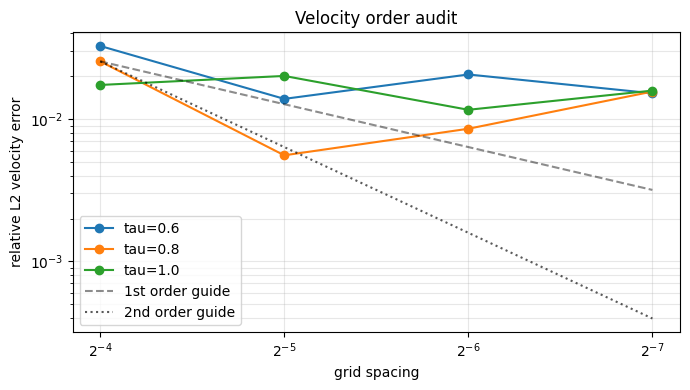

In [4]:
plot_error_with_guides("velocity_relative_l2_error", "relative L2 velocity error", "Velocity order audit")
print_orders("velocity_relative_l2_error")

Vorticity is a stricter derived-field diagnostic because it depends on spatial derivatives. It can expose phase and structure errors that are less visible in velocity alone.

tau=0.6: 1.93, 1.95, 0.72
tau=0.8: 1.86, 2.08, 1.54
tau=1.0: 0.86, -0.18, 2.60


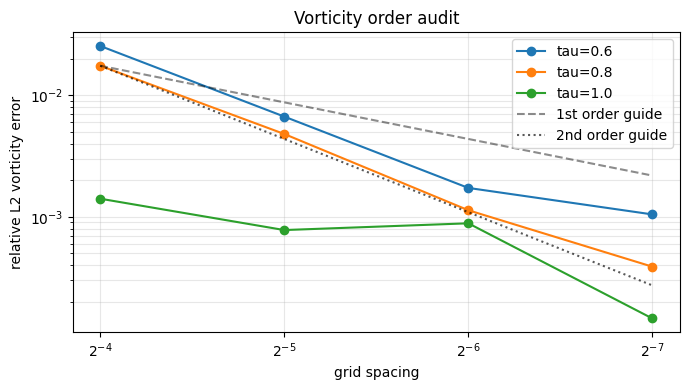

In [5]:
plot_error_with_guides("vorticity_relative_l2_error", "relative L2 vorticity error", "Vorticity order audit")
print_orders("vorticity_relative_l2_error")

Kinetic energy decay gives a scalar check on whether the simulated viscous damping follows the analytic Taylor-Green decay.

tau=0.6: 1.93, 2.11, 1.06
tau=0.8: 1.86, 2.14, 2.13
tau=1.0: 1.56, -0.28, 5.64


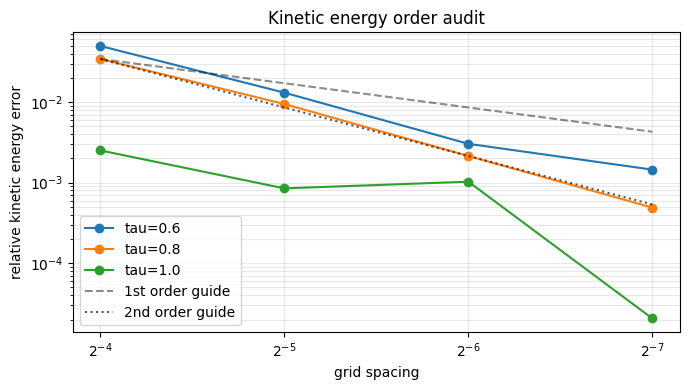

In [6]:
plot_error_with_guides("kinetic_energy_relative_error", "relative kinetic energy error", "Kinetic energy order audit")
print_orders("kinetic_energy_relative_error")

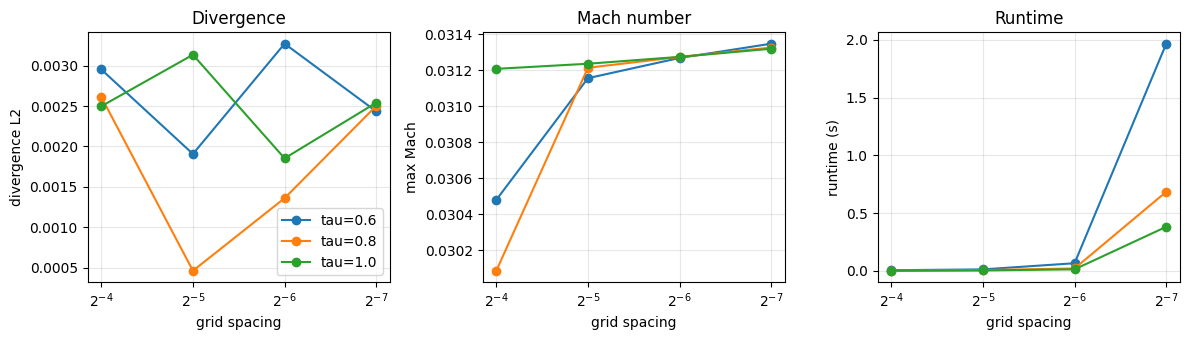

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, metric, ylabel, title in [
    (axes[0], "divergence_l2_norm", "divergence L2", "Divergence"),
    (axes[1], "max_mach", "max Mach", "Mach number"),
    (axes[2], "runtime_seconds", "runtime (s)", "Runtime"),
]:
    for tau in sorted({record.tau for record in records}):
        subset = sorted([record for record in records if record.tau == tau], key=lambda record: record.grid_spacing, reverse=True)
        ax.plot([record.grid_spacing for record in subset], [getattr(record, metric) for record in subset], marker="o", label=f"tau={tau}")
    ax.set_xscale("log", base=2)
    ax.invert_xaxis()
    ax.set_xlabel("grid spacing")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.3)
axes[0].legend()
fig.tight_layout()

## Analysis of Current Order-Study Outputs

The order study is the most important result so far. It does not give a clean second-order velocity-convergence story. Some vorticity and kinetic-energy segments are close to second order, especially at moderate refinement, but velocity error is not monotonic across grids for several `tau` values. The validation gate now marks such cases as `investigation_required` rather than silently treating stable finite outputs as sufficient evidence. That means replacing the solver immediately with a different second-order LBE would be premature; we first need to identify which error source is dominating the velocity field.

My current interpretation is that the baseline BGK D2Q9 implementation is stable and useful for classical diagnosis, but it is not validated for downstream quantum-circuit or resource-estimation work while the default velocity-convergence assessment remains non-passing. The validation protocol may be mixing weak compressibility, density/pressure initialization, discrete timestep rounding for fixed decay, and long-time accumulated kinetic-mode error at fine grids. These can mask the formal second-order behavior expected from the standard smooth periodic LBM setting.


In [ ]:
order_fields = [
    "velocity_observed_order",
    "vorticity_observed_order",
    "kinetic_energy_observed_order",
]
for tau in sorted({record.tau for record in records}):
    subset = [record for record in records if record.tau == tau]
    print(f"tau={tau}")
    for field in order_fields:
        values = [getattr(record, field) for record in subset]
        values = [value for value in values if value is not None]
        formatted = ", ".join(f"{value:.2f}" for value in values)
        print(f"  {field}: {formatted}")
    velocity_errors = [record.velocity_relative_l2_error for record in sorted(subset, key=lambda record: record.grid_spacing, reverse=True)]
    print("  velocity errors:", ", ".join(f"{value:.3e}" for value in velocity_errors))
    statuses = sorted({record.validation_status for record in subset})
    blockers = sorted({record.validation_blocker for record in subset if record.validation_blocker})
    print("  validation status:", ", ".join(statuses))
    print("  validation blockers:", ", ".join(blockers))
    print("  passed for quantum follow-up:", any(record.passed_for_quantum_followup for record in subset))


Conclusion: do not switch to a new LBE yet. The next numerical step should be a controlled error-source study, not a solver replacement.

Recommended follow-up experiments:

1. Repeat the order study at lower amplitudes such as `0.005`, `0.01`, and `0.02` to measure compressibility sensitivity.
2. Compare different Taylor-Green density initializations: constant density, current pressure-corrected density, and possibly incompressible-style initialization.
3. Reduce timestep-rounding effects by reporting actual decay exponent and grouping cases with nearly identical actual decay.
4. Add an optional `256x256` run only after the lower-amplitude study clarifies whether fine-grid velocity error is physical, numerical, or diagnostic.
5. Only after that comparison should we implement an incompressible He-Luo, TRT, or MRT variant.

This also means the quantum path must stay gated: D1Q3 can remain the simpler classical operator-emulation target, while D2Q9 should stay in classical diagnosis until its error behavior is better understood or a simpler validated target is selected intentionally.
